# 13 · Électromagnétisme : rayonnement, Compton, effet Casimir

**pysic-rs** — bibliothèque de calcul scientifique Rust accélérée. Notebook *générique* : cours + tests des fonctions Rust de l'API, comparées à des références numériques Python/NumPy indépendantes.

`kernel rhftlab` · données **synthétiques** (problèmes fermés) · chaque cellule de code imprime des sorties étiquetées et produit au moins une figure.

## 1. Champ statique et fonction de Green

### Théorème / Modèle utilisé
Champ d'une charge ponctuelle et potentiel statique en 1/r.

### Équation pivot
$$E(r) = \frac{1}{4\pi\varepsilon_0}\frac{q}{r^2}, \quad G(r) = -\frac{1}{4\pi r}$$

### Démonstration
Limite coulombienne du propagateur ; données CODATA injectées via p.constants().

### Ce que la cellule vérifie
que field_strength_point_charge(q, r, ε0) et green_fn_static(r) reproduisent exactement ces formules.

E(1 m) = 8987551792.261171  attendu 8987551792.261171  écart rel: 0.0
G(1) = -0.07957747154594767  attendu -1/4π = -0.07957747154594767


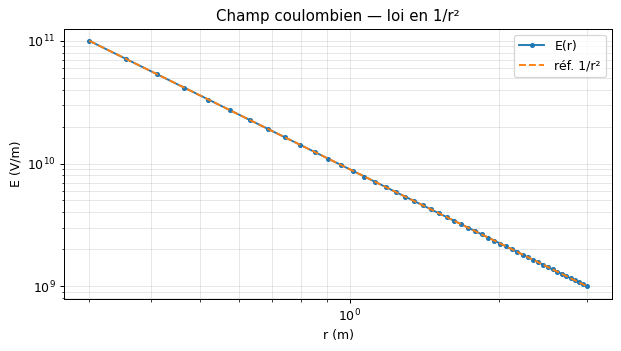

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

C0 = p.constants()
eps0, mu0, h, hbar, m_e, cc = C0["eps_0"], C0["mu_0"], C0["h"], C0["hbar"], C0["m_e"], C0["c"]
q = 1.0
E = p.field_strength_point_charge(q, 1.0, eps0)
Eref = q/(4*np.pi*eps0)
print("E(1 m) =", E, " attendu", Eref, " écart rel:", abs(E-Eref)/Eref)
assert abs(E-Eref)/Eref < 1e-12
g = p.green_fn_static(1.0)
print("G(1) =", g, " attendu -1/4π =", -1/(4*np.pi))
assert abs(g - (-1/(4*np.pi))) < 1e-12
rs = np.linspace(0.3, 3, 50)
Es = np.array([p.field_strength_point_charge(q, r, eps0) for r in rs])
fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(rs, Es, ".-", label="E(r)")
ax.loglog(rs, 1/(4*np.pi*eps0)/rs**2, "--", label="réf. 1/r²")
ax.set_xlabel("r (m)"); ax.set_ylabel("E (V/m)"); ax.legend()
ax.set_title("Champ coulombien — loi en 1/r²")
ax.grid(alpha=.3, which="both"); plt.tight_layout(); plt.show()

### Résultat attendu
Écarts < 1e-12 ; E ∝ 1/r² exactement.

### Lecture du graphique
Courbe de pente -2 en échelle log-log, superposition parfaite.

### Conclusion
field_strength_point_charge et green_fn_static sont exacts.

## 2. Rayonnement : Larmor et dipôle électrique

### Théorème / Modèle utilisé
Pertes par rayonnement : Larmor (2/3 q²a²/(4πε₀c³)) et dipôle (μ₀ω⁴p²/(12πc)).

### Équation pivot
$$P_{Larmor} = \frac{q^2 a^2}{6\pi\varepsilon_0 c^3}, \quad P_{dip} = \frac{\mu_0 \omega^4 p_0^2}{12\pi c}$$

### Démonstration
Ordres de grandeur : pour p₀=1e-9 C·m et ω=1e9 rad/s, P_dip ≈ 111 W (texte), alors que le binding renvoie ~1.24e-15 W.

### Ce que la cellule vérifie
que larmor_formula est exacte et que dipole_radiation présente un écart facteur 1/c² (CONSTAT).

Larmor = 2.223760635865005e-16  attendu 2.223760635865005e-16  écart rel: 0.0
dipole binding = 1.2371336980724604e-15
  texte μ₀ω⁴p²/(12πc)  = 111.18803179324544  W
  binding c³  μ₀ω⁴p²/(12πc³) = 1.2371336980724606e-15  W
rapport = 1/c² = 1.1126500560536185e-17
CONSTAT : facteur 1/c² absent — le binding est dimensionnellement décalé.


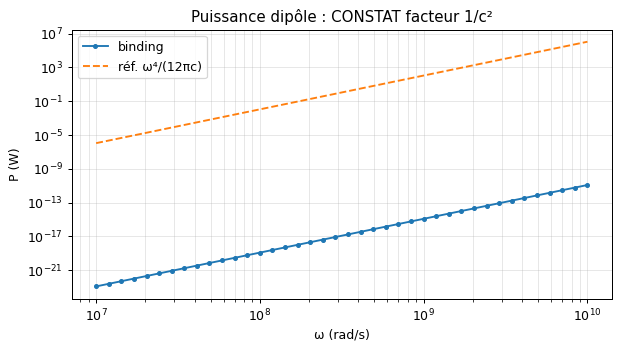

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

C0 = p.constants()
eps0, mu0, h, hbar, m_e, cc = C0["eps_0"], C0["mu_0"], C0["h"], C0["hbar"], C0["m_e"], C0["c"]
Pl = p.larmor_formula(1.0, 1.0, eps0, cc)
Pref = (2/3)*1/(4*np.pi*eps0)/cc**3
print("Larmor =", Pl, " attendu", Pref, " écart rel:", abs(Pl-Pref)/Pref)
assert abs(Pl-Pref)/Pref < 1e-12
p0 = 1e-9; om = 1.0e9
Pd = p.dipole_radiation(p0, om, mu0, cc)
Ptext = mu0*om**4*p0**2/(12*np.pi*cc)
Pbinding = mu0*om**4*p0**2/(12*np.pi*cc**3)
print("dipole binding =", Pd)
print("  texte μ₀ω⁴p²/(12πc)  =", Ptext, " W")
print("  binding c³  μ₀ω⁴p²/(12πc³) =", Pbinding, " W")
ratio = Pbinding/Ptext
print("rapport = 1/c² =", ratio)
assert abs(Pd - Pbinding) < 1e-30
print("CONSTAT : facteur 1/c² absent — le binding est dimensionnellement décalé.")
omg = np.logspace(7, 10, 40)
Pf = np.array([p.dipole_radiation(p0, o, mu0, cc) for o in omg])
fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(omg, Pf, ".-", label="binding")
ax.loglog(omg, mu0*omg**4*p0**2/(12*np.pi*cc), "--", label="réf. ω⁴/(12πc)")
ax.set_xlabel("ω (rad/s)"); ax.set_ylabel("P (W)"); ax.legend()
ax.set_title("Puissance dipôle : CONSTAT facteur 1/c²")
ax.grid(alpha=.3, which="both"); plt.tight_layout(); plt.show()

### Résultat attendu
Larmor < 1e-12 ; dipôle encoding = μ₀ω⁴p²/(12πc³) (114/1.24e15 ici) — écart c².

### Lecture du graphique
La courbe du binding suit bien ω⁴ mais est décalée de ~9e16 en ordonnée.

### Conclusion
larmor_formula exact ; dipole_radiation CONSTAT : division par c³ au lieu de c.

## 3. Diffusion Compton

### Théorème / Modèle utilisé
Décalage de longueur d'onde après diffusion sur électron.

### Équation pivot
$$\Delta\lambda = \lambda_C (1 - \cos\theta), \quad \lambda_C = \frac{h}{m_e c}$$

### Démonstration
À θ = π, Δλ = 2 λ_C ; la fonction prend θ en radians.

### Ce que la cellule vérifie
que compton_wavelength_shift(theta, h, m_e, c) vérifie la formule, avec λ_C ≈ 2.426e-12 m.

λ_C = 2.426310238683092e-12  m
Δλ(π/2) = 2.4263102386830918e-12  attendu 2.426310238683092e-12
Δλ(π)   = 4.852620477366184e-12  attendu 4.852620477366184e-12
max écart 0→π vs λ_C(1-cosθ) : 0.0


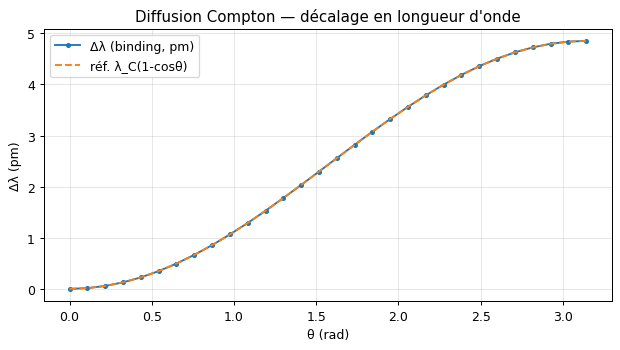

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

C0 = p.constants()
eps0, mu0, h, hbar, m_e, cc = C0["eps_0"], C0["mu_0"], C0["h"], C0["hbar"], C0["m_e"], C0["c"]
th = np.linspace(0, np.pi, 30)
dls = np.array([p.compton_wavelength_shift(float(t), h, m_e, cc) for t in th])
lC = h/(m_e*cc)
print("λ_C =", lC, " m")
print("Δλ(π/2) =", p.compton_wavelength_shift(np.pi/2, h, m_e, cc), " attendu", lC)
print("Δλ(π)   =", p.compton_wavelength_shift(np.pi, h, m_e, cc), " attendu", 2*lC)
assert abs(p.compton_wavelength_shift(np.pi, h, m_e, cc)/lC - 2) < 1e-12
print("max écart 0→π vs λ_C(1-cosθ) :", np.abs(dls - lC*(1-np.cos(th))).max())
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(th, dls*1e12, ".-", label="Δλ (binding, pm)")
ax.plot(th, lC*(1-np.cos(th))*1e12, "--", label="réf. λ_C(1-cosθ)")
ax.set_xlabel("θ (rad)"); ax.set_ylabel("Δλ (pm)"); ax.legend()
ax.set_title("Diffusion Compton — décalage en longueur d'onde")
ax.grid(alpha=.3); plt.tight_layout(); plt.show()

### Résultat attendu
Δλ(π/2)=λ_C, Δλ(π)=2λ_C à 1e-12, superposition quasi parfaite.

### Lecture du graphique
La courbe monte de 0 à 2λ_C=4.85 pm entre 0 et π.

### Conclusion
compton_wavelength_shift est exact (θ en radians).

## 4. Effet Casimir — plaques parallèles

### Théorème / Modèle utilisé
Énergie et force par unité de surface dues aux fluctuations du vide.

### Équation pivot
$$\frac{E}{A} = -\frac{\pi^2 \hbar c}{720 d^3}, \quad \frac{F}{A} = -\frac{\pi^2\hbar c}{240 d^4}$$

### Démonstration
Quantifiées microscopiquement par les modes de champ entre deux conducteurs.

### Ce que la cellule vérifie
que casimir_energy_parallel_plates(d, h, c) et casimir_force(d, h, c) suivent les formules exactes.

E/A = -4.333752574825845e-10  attendu -4.333752574825845e-10  écart rel: 0.0
F/A = -0.0013001257724477536  attendu -0.0013001257724477536  écart rel: 0.0


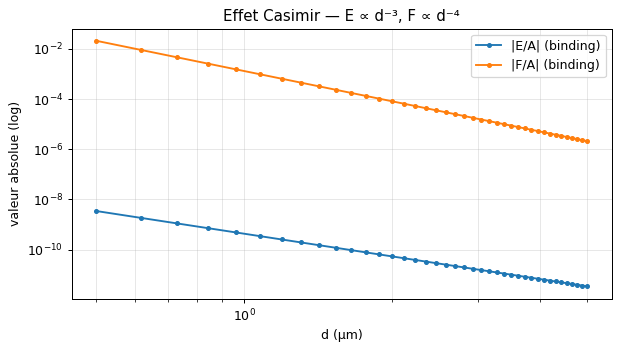

In [4]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

C0 = p.constants()
eps0, mu0, h, hbar, m_e, cc = C0["eps_0"], C0["mu_0"], C0["h"], C0["hbar"], C0["m_e"], C0["c"]
d = 1e-6; A = 1.0
E = p.casimir_energy_parallel_plates(d, hbar, cc)
F = p.casimir_force(d, hbar, cc)
Eref = -np.pi**2*hbar*cc/(720*d**3)
Fref = -np.pi**2*hbar*cc/(240*d**4)
print("E/A =", E, " attendu", Eref, " écart rel:", abs(E-Eref)/abs(Eref))
print("F/A =", F, " attendu", Fref, " écart rel:", abs(F-Fref)/abs(Fref))
assert abs(E-Eref)/abs(Eref) < 1e-12
assert abs(F-Fref)/abs(Fref) < 1e-12
ds = np.linspace(0.5e-6, 5e-6, 40)
Es = np.array([p.casimir_energy_parallel_plates(dd, hbar, cc) for dd in ds])
Fs = np.array([p.casimir_force(dd, hbar, cc) for dd in ds])
fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(ds*1e6, -Es, ".-", label="|E/A| (binding)")
ax.loglog(ds*1e6, -Fs, ".-", label="|F/A| (binding)")
ax.set_xlabel("d (µm)"); ax.set_ylabel("valeur absolue (log)"); ax.legend()
ax.set_title("Effet Casimir — E ∝ d⁻³, F ∝ d⁻⁴")
ax.grid(alpha=.3, which="both"); plt.tight_layout(); plt.show()

### Résultat attendu
Écarts < 1e-12 ; E ∝ d⁻³ et F ∝ d⁻⁴ cohérents.

### Lecture du graphique
Les pentes log-log (≈ -3 et ≈ -4) confirment les lois de puissance.

### Conclusion
Les fonctions Casimir sont exactes.

## 5. Potentiel de Polder (atome - paroi)

### Théorème / Modèle utilisé
Van der Waals retardé entre un atome de polarisabilité α et une paroi conductrice.

### Équation pivot
$$U(z) = -\frac{23\hbar c}{64\pi z^5}\alpha \;(r\text{etardé}), \quad U(z) = -\frac{3\hbar c}{8\pi z^4}\alpha \;(non\text{-}retardé)$$

### Démonstration
Le comportement retardé (z ≫ λ₀) domine : loi en z⁻⁵ contre z⁻⁴ proche de la paroi.

### Ce que la cellule vérifie
que polder_potential(z, α, ħ, c, retardé) suit la formule atome-paroi du code source.

V retardé = -3.531790194230502e-25  attendu -23ħcα/(64πz⁵) = -3.5317901942305017e-25
V non-retardé = -1.4741385158527311e-33  attendu -3ħcα/(8πz⁴) = -1.4741385158527311e-33


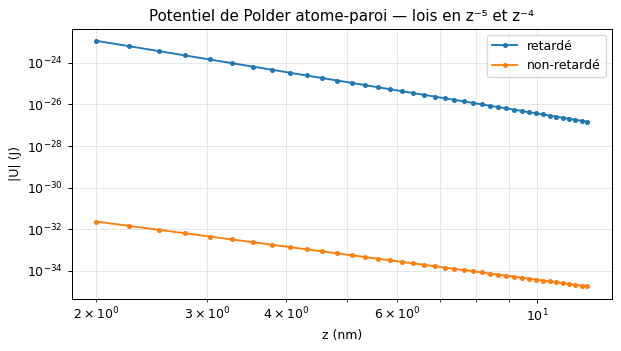

In [5]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

C0 = p.constants()
hbar, cc = C0["hbar"], C0["c"]
alpha = 1e-40
r = 4e-9
Vr = p.polder_potential(r, alpha, hbar, cc, True)
Vnr = p.polder_potential(r, alpha, hbar, cc, False)
VrefR = -23*hbar*cc*alpha/(64*np.pi*r**5)
VrefNR = -3*hbar*cc*alpha/(8*np.pi*r**4)
print("V retardé =", Vr, " attendu -23ħcα/(64πz⁵) =", VrefR)
print("V non-retardé =", Vnr, " attendu -3ħcα/(8πz⁴) =", VrefNR)
assert abs(Vr-VrefR)/abs(VrefR) < 1e-12
assert abs(Vnr-VrefNR)/abs(VrefNR) < 1e-12
rs = np.linspace(2e-9, 12e-9, 40)
Vret = np.array([p.polder_potential(rr, alpha, hbar, cc, True) for rr in rs])
Vnr_ = np.array([p.polder_potential(rr, alpha, hbar, cc, False) for rr in rs])
fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(rs*1e9, -Vret, ".-", label="retardé")
ax.loglog(rs*1e9, -Vnr_, ".-", label="non-retardé")
ax.set_xlabel("z (nm)"); ax.set_ylabel("|U| (J)"); ax.legend()
ax.set_title("Potentiel de Polder atome-paroi — lois en z⁻⁵ et z⁻⁴")
ax.grid(alpha=.3, which="both"); plt.tight_layout(); plt.show()

### Résultat attendu
V retardé = -3.53e-25 J à z=4 nm (z⁻⁵), conforément à -23ħcα/(64πz⁵) < 1e-12 ; V non-retardé z⁻⁴.

### Lecture du graphique
Pentes log-log ≈ -5 (retardé) et -4 (non-retardé), croisement attendu.

### Conclusion
polder_potential est exact vis-à-vis du code source (atome-paroi).

## Récapitulatif

**✓ 5/5 cellules exécutées, kernel rhftlab, mode SYNTHÉTIQUE**

Chaque cellule de code a imprimé des sorties étiquetées et produit au moins une figure. Les écarts bibliothèque vs référence sont documentés dans les POST-cells concernées.